# Week 6 Case Study: Finding Unusual Expense Reports with Linear Regression
### Meridian Fixtures Inc. | Travel Expense Reports, January–June 2026

The Controller wants a faster way to spot travel expense reports that deserve a second look. Your team will build a simple linear regression that predicts a trip's **total cost** from its **length in days**, then use it to find reports that don't fit the pattern.

**How to use this notebook**
- Run each code cell in order: click in the cell and press **Shift + Enter**.
- Most of the code is written for you. In a few places you'll see **`FILL_IN`**. Replace it with the right value (hints are in the comments), then run the cell.
- Blue-heading cells marked ✍️ contain questions. Double-click the cell and type your answer under the question.
- If a cell gives an error, read the last line of the error message first. It usually tells you what went wrong.

## Task 0: Setup (≈5 min)

**Before you start:** make sure `travel_expenses_STUDENT.csv` is in the same folder as this notebook.
- *Google Colab:* click the folder icon on the left sidebar, then the upload button, and upload the CSV.
- *Jupyter / VS Code:* save the CSV in the same folder as this notebook.

Run the cell below to load the tools we'll use: **pandas** (tables), **matplotlib** (charts), and **scipy.stats** (the regression).

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print("Libraries loaded.")

Libraries loaded.


In [4]:
# Create timestamp and author
from datetime import datetime
#time_now = datetime.now().strftime('%m_%d_%Y_%I%M%p')
#print("Current Time:{}".format(time_now))
#print("Set Phyoe")

In [5]:
df = pd.read_csv("travel_expenses_STUDENT.csv")

print("Rows:", len(df))
df.head(10)

Rows: 129


,report_id,employee,destination,purpose,trip_start,trip_end,days_claimed,total_cost
0,TR-2001,S. Patel,"Phoenix, AZ",Customer visit,2026-02-28,2026-03-02,3,1158.78
1,TR-2002,J. Alvarez,"Chicago, IL",Trade show,2026-04-24,2026-04-27,4,1569.82
2,TR-2003,M. Chen,"Dallas, TX",Installation support,2026-05-29,2026-05-30,2,1160.97
3,TR-2004,R. Osei,"Nashville, TN",Supplier audit,2026-05-11,2026-05-16,6,2198.36
4,TR-2005,K. Brooks,"Chicago, IL",Customer visit,2026-06-07,2026-06-10,4,1604.76
5,TR-2006,R. Osei,"Columbus, OH",Supplier audit,2026-06-03,2026-06-08,6,2186.28
6,TR-2007,M. Chen,"Minneapolis, MN",Supplier audit,2026-05-28,2026-06-01,5,1869.82
7,TR-2008,T. Nguyen,"Columbus, OH",Sales training,2026-02-14,2026-02-14,1,646.62
8,TR-2009,S. Patel,"Atlanta, GA",Trade show,2026-03-28,2026-03-30,3,1104.09
9,TR-2010,K. Brooks,"Nashville, TN",Trade show,2026-03-20,2026-03-22,3,1056.73


## Task 1: Look Before You Model (≈5 min)

Always look at the data before fitting anything. The next cell gives summary statistics for the numeric columns.

In [6]:
df.describe().round(2)  #round(2) means round to 2 decimal points

,days_claimed,total_cost
count,129.00,129.00
mean,4.02,1683.39
std,2.27,1303.87
min,1.00,-1186.40
25%,3.00,1160.97
50%,3.00,1516.62
75%,5.00,2027.02
max,18.00,13482.50


Now plot every trip: days on the horizontal axis (x), cost on the vertical axis (y).

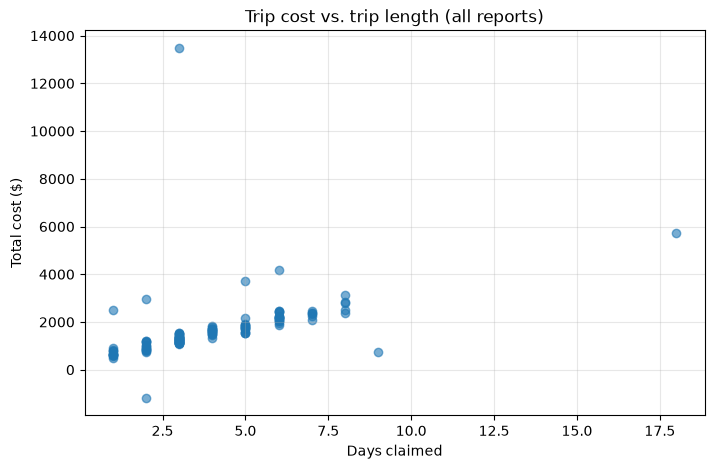

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df["days_claimed"], df["total_cost"], alpha=0.6) #alpha 0.6 relates to the fill of the dots
plt.xlabel("Days claimed")
plt.ylabel("Total cost ($)")
plt.title("Trip cost vs. trip length (all reports)")
plt.grid(alpha=0.3)
plt.show()

### ✍️ Task 1 Questions
1. Look at the `min` and `max` rows for `total_cost` in the summary table. Does anything look impossible or suspicious for a business trip? Why?
2. Describe the overall pattern in the scatter plot in one sentence. Does cost seem to rise with trip length?
3. Which points (if any) stand out on the chart just by eye?

*Your answers:* 
1. The point that is below $0 total cost is impossible.
2. The overall pattern is positive linear relationship with some outliers.
3. There are 2 points that stand out. (2.7, 13800) and (17.7, 5900)

## Task 2: Fit a Line to All the Data (≈10 min)

Linear regression finds the straight line that best fits the points:

**predicted cost = intercept + slope × days**

In the cell below, fill in the two column names:
- `x` is the **driver**: the thing we think explains cost.
- `y` is what we're **predicting**.

In [8]:
x = df["days_claimed"]     # HINT: the column with the number of days
y = df["total_cost"]     # HINT: the column with the dollar amount

fit_all = stats.linregress(x, y)

print(f"Slope:     ${fit_all.slope:,.2f} per extra day")
print(f"Intercept: ${fit_all.intercept:,.2f}")
print(f"R-squared: {fit_all.rvalue**2:.3f}")

Slope:     $256.32 per extra day
Intercept: $654.15
R-squared: 0.199


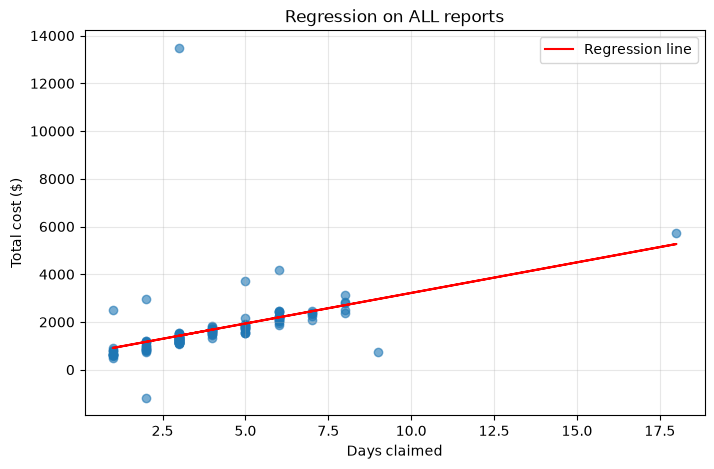

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)
plt.plot(x, fit_all.intercept + fit_all.slope * x, color="red", label="Regression line")
plt.xlabel("Days claimed")
plt.ylabel("Total cost ($)")
plt.title("Regression on ALL reports")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ✍️ Task 2 Questions
1. Explain the **slope** in plain business language (e.g., "each extra day of travel adds about $___").
2. Explain the **intercept**. What real trip costs might it represent even for a very short trip?
3. R-squared tells you what share of the variation in cost is explained by trip length (0 = none, 1 = all). Is this R-squared high or low? Look back at your scatter plot: what might be dragging it down?

*Your answers:*
1. Each extra day of travel adds about $256.32 to the cost.
2. The base trip cost is $654.15 even for a very short trip.
3. R^2 is 0.199 and it's getting dragged down by the outlier point. The short trip with a very high budget and the negative cost point.

## Task 3: Remove the Obvious Errors and Refit (≈10 min)

Meridian's travel policy says:
- **No trip may exceed $8,000 without CFO pre-approval, and none was granted from January to June 2026.**
- A trip report can't have a **negative** total. (Refunds are handled in a different system.)

These are **rule** violations. We don't need a model to catch them, and leaving them in will distort the model. Fill in the policy cap below.

In [10]:
POLICY_CAP = 8000     # HINT: the dollar limit from the policy above (no $ sign or commas)

errors   = df[(df["total_cost"] <= 0) | (df["total_cost"] >= POLICY_CAP)]
df_clean = df[(df["total_cost"] > 0) & (df["total_cost"] < POLICY_CAP)].copy()

print("Rows before:", len(df), "| Rows after:", len(df_clean))
errors

Rows before: 129 | Rows after: 127


,report_id,employee,destination,purpose,trip_start,trip_end,days_claimed,total_cost
119,TR-2120,S. Patel,"Atlanta, GA",Customer visit,2026-03-30,2026-03-31,2,-1186.4
127,TR-2128,R. Osei,"Dallas, TX",Customer visit,2026-02-17,2026-02-19,3,13482.5


In [11]:
fit_clean = stats.linregress(df_clean["days_claimed"], df_clean["total_cost"])

print(f"Slope:     ${fit_clean.slope:,.2f} per extra day") #note the f after .2 etc is for formatting
print(f"Intercept: ${fit_clean.intercept:,.2f}")
print(f"R-squared: {fit_clean.rvalue**2:.3f}")

Slope:     $268.13 per extra day
Intercept: $530.01
R-squared: 0.677


### ✍️ Task 3 Questions
1. Fill in this comparison:

| | All data (Task 2) | Cleaned data (Task 3) |
|---|---|---|
| Slope | | |
| Intercept | | |
| R-squared | | |

2. How many reports did the policy check remove? What happened to R-squared, and why do you think two reports out of 129 made that much difference?
3. Look at the `errors` table. For each report, what's the most likely explanation? (Hint: compare the amount to what a typical trip of that length costs.)

*Your answers:*
2. The policy check removed 2 reports. The R^2 improved and it make such a difference because we removed the 2 outliers.
3. The first trip total cost is in negative and the second trip total cost is relatively high compare to other trips with the similar length.

## Task 4: Use Residuals to Find the Outliers (≈20 min)

A **residual** is how far a report is from the line:

**residual = actual cost − predicted cost**

A big positive residual means the trip cost much **more** than expected for its length. A big negative residual means much **less**. We'll flag any report whose residual is more than **2 standard deviations** from zero. Fill in the multiplier below.

In [12]:
df_clean["predicted"] = fit_clean.intercept + fit_clean.slope * df_clean["days_claimed"]
df_clean["residual"]  = df_clean["total_cost"] - df_clean["predicted"]

SD_MULTIPLIER = 2    # HINT: how many standard deviations? (see the text above)
cutoff = SD_MULTIPLIER * df_clean["residual"].std()
print(f"Flag any report more than ${cutoff:,.2f} above or below the line")

df_clean["flag"] = df_clean["residual"].abs() > cutoff
flagged = df_clean[df_clean["flag"]]

print("Reports flagged:", len(flagged))
flagged[["report_id", "employee", "destination", "purpose",
         "days_claimed", "total_cost", "predicted", "residual"]].round(2)

Flag any report more than $844.22 above or below the line
Reports flagged: 5


,report_id,employee,destination,purpose,days_claimed,total_cost,predicted,residual
18,TR-2019,T. Nguyen,"Columbus, OH",Supplier audit,9,742.10,2943.17,-2201.07
34,TR-2035,M. Chen,"Monterrey, MX",Supplier audit,6,4185.60,2138.78,2046.82
59,TR-2060,M. Chen,"Nashville, TN",Customer visit,2,2968.75,1066.27,1902.48
80,TR-2081,J. Alvarez,"Denver, CO",Sales training,5,3712.30,1870.65,1841.65
83,TR-2084,R. Osei,"Phoenix, AZ",Customer visit,1,2500.00,798.14,1701.86


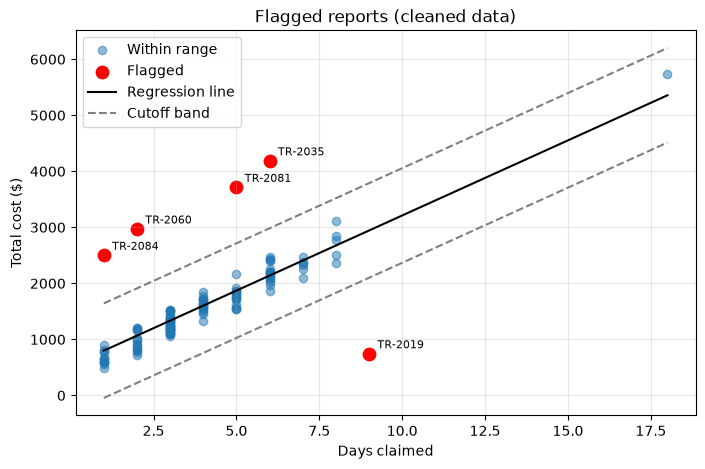

In [13]:
normal = df_clean[~df_clean["flag"]]
xs = df_clean["days_claimed"].sort_values()

plt.figure(figsize=(8, 5))
plt.scatter(normal["days_claimed"], normal["total_cost"], alpha=0.5, label="Within range")
plt.scatter(flagged["days_claimed"], flagged["total_cost"], color="red", s=80, label="Flagged")
plt.plot(xs, fit_clean.intercept + fit_clean.slope * xs, color="black", label="Regression line")
plt.plot(xs, fit_clean.intercept + fit_clean.slope * xs + cutoff, "--", color="gray", label="Cutoff band")
plt.plot(xs, fit_clean.intercept + fit_clean.slope * xs - cutoff, "--", color="gray")
for _, row in flagged.iterrows():
    plt.annotate(row["report_id"], (row["days_claimed"], row["total_cost"]),
                 textcoords="offset points", xytext=(6, 4), fontsize=8)
plt.xlabel("Days claimed")
plt.ylabel("Total cost ($)")
plt.title("Flagged reports (cleaned data)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ✍️ Task 4 Questions
1. Complete the **investigation table** on your answer sheet: for each flagged report, give a likely explanation and a recommended action (**Approve**, **Ask the employee**, or **Reject**). Use every column, including `destination` and `purpose`, and look at the trip dates in the full data (`df[df["report_id"] == "TR-____"]`).
2. Is every flagged report a problem? Find at least one that might be legitimate, and explain what the model doesn't know about it.
3. Change `SD_MULTIPLIER` to **3** and re-run the two cells above. Does the list change? What's the trade-off between a lower and a higher cutoff for an audit team? (Set it back to 2 when you're done.)
4. One trip in the data is much longer than the others. Find it on the chart. Is it flagged? Why is a trip with an unusual **x-value** not necessarily an outlier?

*Your answers:*
2. For the TR-2019 it's clear that it might not be a problem because the trip is only 1 day but it's claimed as 9 days. The model didn't take this into account.
3. The list is still the same but the cutoffband is closer to the flagged items. The higher cutoff means that there's a more leeway compared to the lower cutoff.
4. TR-2085 is the one with the longest trip. Although it's longer than others, it doesn't necessarily mean an outlier because the total cost is still within a reasonable range for the amount of days traveld based on our linear model.

## Task 5: Adversarial Test: What Did the Model Miss? (≈10 min)

A regression only asks one question: *"Is this cost unusual for this many days?"* Think like someone trying to get a bad report past it.

**Check A: Duplicate submissions.** A report submitted twice has a perfectly normal amount, so it sits right on the line.

In [14]:
dupes = df[df.duplicated(subset=["employee", "trip_start", "trip_end", "total_cost"], keep=False)]
dupes

,report_id,employee,destination,purpose,trip_start,trip_end,days_claimed,total_cost
38,TR-2039,K. Brooks,"Chicago, IL",Trade show,2026-03-09,2026-03-12,4,1631.4
75,TR-2076,K. Brooks,"Chicago, IL",Trade show,2026-03-09,2026-03-12,4,1631.4


**Check B: Days that don't match the dates.** The model trusts `days_claimed`. What if the employee inflated the days so a padded cost looks normal?

In [15]:
df["days_from_dates"] = (pd.to_datetime(df["trip_end"]) - pd.to_datetime(df["trip_start"])).dt.days + 1

mismatch = df[df["days_from_dates"] != df["days_claimed"]]
mismatch[["report_id", "employee", "trip_start", "trip_end",
          "days_claimed", "days_from_dates", "total_cost"]]

,report_id,employee,trip_start,trip_end,days_claimed,days_from_dates,total_cost
17,TR-2018,T. Nguyen,2026-05-26,2026-05-28,7,3,2461.85
18,TR-2019,T. Nguyen,2026-01-27,2026-01-27,9,1,742.10


### ✍️ Task 5 Questions
1. Which reports did these two checks find that the regression **did not** flag? Why couldn't regression catch them?
2. For the days mismatch: use the regression equation from Task 3 to calculate what the report *should* have cost for the actual number of days. How much might the company be overpaying?
3. In two or three sentences: if you were designing Meridian's expense review process, where would you use regression, and where would you use simple rules? Why do you need both?

*Your answers:*
1. The regression did not catch the duplicate reports because the regression can only check whether the data is in a reasonable range. It also did not catch the wrong days because the model relied on the days claimed in the report is true.
2. For TR-2018, with the actual number of days, it should've cost only $1334.4. The company is overpaying $1127.45. For TR-2019, it should've $798.14 but it only cost $742.10.
3. I would use the regression rule to check whether the cost is within a reasonable budget. But, when checking whether the datas the employee reported is true and correct, I would use a simple rule. I need both because the regression model cannot catch errors in the data.

## Task 6: Fact-Check an AI-Drafted Audit Memo (≈20 min)

Meridian's accounts payable team pasted the flagged reports into an AI assistant and asked it to draft a memo to the Controller. The draft is below. **It reads well, and it contains several errors.** Your job is to find them before the Controller acts on it.

### Part A: Check the draft (≈12 min)

---

> **MEMO (AI-generated draft)**
>
> **To:** Controller, Meridian Fixtures Inc.
> **From:** AI Audit Assistant
> **Re:** Travel expense reports flagged for review, January–June 2026
>
> **Summary.** We fit a linear regression of total trip cost on days claimed for all travel expense reports submitted from January to June 2026. After removing two reports that violate travel policy (TR-2128 and TR-2120), the model flagged six reports as unusual. The model's R-squared of 0.95 shows that it predicts trip costs with a high degree of accuracy, so these flags can be acted on with confidence.
>
> **TR-2035 (M. Chen, Monterrey, MX, $4,185.60).** This is the largest positive outlier, $2,047 above the expected cost for a 6-day trip. Costs this far above the norm strongly suggest fraudulent padding. **Recommendation: Reject.**
>
> **TR-2060 (M. Chen, Nashville, TN, $2,968.75).** This 2-day customer visit cost $1,902 more than expected, nearly three times the predicted amount. **Recommendation: Request itemized receipts before approving.**
>
> **TR-2081 (J. Alvarez, Denver, CO, $3,712.30).** This 5-day trip is $1,842 above expected and exceeds Meridian's $150-per-day meal allowance. **Recommendation: Request itemized receipts before approving.**
>
> **TR-2084 (R. Osei, Phoenix, AZ, $2,500.00).** Mr. Osei has confirmed that this amount was a flat conference registration fee. **Recommendation: Approve.**
>
> **TR-2019 (T. Nguyen, Columbus, OH, $742.10).** This 9-day trip came in $2,201 under the expected cost, which shows excellent cost discipline. **Recommendation: Approve, and consider recognizing the employee.**
>
> **Conclusion.** All other reports fall within the expected range and can be approved without further review.

---

Run the cell below. It prints the facts you'll need to check the memo against.

In [16]:
print("Reports flagged by the model:", len(flagged))
print(f"R-squared of the model used for flagging (Task 3): {fit_clean.rvalue**2:.3f}")
print()
print("Flagged reports, with the trip dates:")
check = df[df["report_id"].isin(flagged["report_id"])]
print(check[["report_id", "employee", "destination", "purpose", "trip_start", "trip_end",
             "days_claimed", "days_from_dates", "total_cost"]].to_string(index=False))

Reports flagged by the model: 5
R-squared of the model used for flagging (Task 3): 0.677

Flagged reports, with the trip dates:
report_id   employee   destination        purpose trip_start   trip_end  days_claimed  days_from_dates  total_cost
  TR-2019  T. Nguyen  Columbus, OH Supplier audit 2026-01-27 2026-01-27             9                1      742.10
  TR-2035    M. Chen Monterrey, MX Supplier audit 2026-02-02 2026-02-07             6                6     4185.60
  TR-2060    M. Chen Nashville, TN Customer visit 2026-04-21 2026-04-22             2                2     2968.75
  TR-2081 J. Alvarez    Denver, CO Sales training 2026-05-11 2026-05-15             5                5     3712.30
  TR-2084    R. Osei   Phoenix, AZ Customer visit 2026-06-03 2026-06-03             1                1     2500.00


### ✍️ Task 6, Part A Questions
1. On your answer sheet, list **every error** you can find in the memo. For each one, write what the memo says, what the data actually shows, and which notebook output proves it. (Look for wrong numbers, invented facts, wrong conclusions, and anything important the memo leaves out. Your policy excerpt in the case study document and your Task 5 results will help.)
2. If the Controller followed the memo exactly as written, which single error would cost Meridian the most, in money or in trust? Why?

*Your answers:*
2. The costliest error is recommending prasing of T. Nguyen because there was clearly an error. If he/she is praised, then others employees might get the same idea and also claim extra days on their report.

### Part B: Generate your own AI memo (≈8 min)

Run the cell below and copy the printed table.

In [17]:
print(flagged[["report_id", "employee", "destination", "purpose",
               "trip_start", "trip_end", "days_claimed",
               "total_cost", "predicted", "residual"]].round(2).to_string(index=False))

report_id   employee   destination        purpose trip_start   trip_end  days_claimed  total_cost  predicted  residual
  TR-2019  T. Nguyen  Columbus, OH Supplier audit 2026-01-27 2026-01-27             9      742.10    2943.17  -2201.07
  TR-2035    M. Chen Monterrey, MX Supplier audit 2026-02-02 2026-02-07             6     4185.60    2138.78   2046.82
  TR-2060    M. Chen Nashville, TN Customer visit 2026-04-21 2026-04-22             2     2968.75    1066.27   1902.48
  TR-2081 J. Alvarez    Denver, CO Sales training 2026-05-11 2026-05-15             5     3712.30    1870.65   1841.65
  TR-2084    R. Osei   Phoenix, AZ Customer visit 2026-06-03 2026-06-03             1     2500.00     798.14   1701.86


Paste the table into an AI assistant with this prompt:

> *"You are an internal auditor at a building-hardware company. Using the table below of travel expense reports flagged by a regression model (cost vs. trip days), write a short memo to the Controller recommending which reports to approve, question, or reject, and why."*

### ✍️ Task 6, Part B Questions
1. Paste your AI's memo on your answer sheet.
2. Did your AI make any of the same **kinds** of mistakes you found in Part A? Give one example, or explain what it did better.
3. Write one rule your team would follow before sending any AI-drafted audit memo to a manager.

*Your answers:*

## Optional Bonus: Refit Without the Flagged Reports

If you finish early, run this cell. It removes the flagged reports and fits the line again.

In [18]:
df_final = df_clean[~df_clean["flag"]]
fit_final = stats.linregress(df_final["days_claimed"], df_final["total_cost"])
print(f"Slope: ${fit_final.slope:,.2f} | Intercept: ${fit_final.intercept:,.2f} | R-squared: {fit_final.rvalue**2:.3f}")

Slope: $291.12 | Intercept: $394.31 | R-squared: 0.946


### ✍️ Bonus Question
R-squared jumps again. Is it fair to report this higher R-squared to management as "how good the model is"? Why or why not?

*Your answer:*
Higher R^2 model doesn't mean that the model is better because the data still contains errors like duplicate reports and wrong days claimed.